## Plotting

In [1]:
from request import Request, RequestType
from simulator import SSDSimulator

ssd = SSDSimulator()

lbas_per_page = ssd.ftl.lbas_per_page()

writes = [Request(RequestType.WRITE, i * lbas_per_page, 0) for i in range(8)]

reads = [
    Request(RequestType.READ, i * lbas_per_page, 50) for i in [0, 4, 1, 5, 2, 6, 3, 7]
]
# ssd.run_simulation(reads + writes)

requests = [
    Request(RequestType.WRITE, 0, 1),
    Request(RequestType.WRITE, 1, 2),
    Request(RequestType.WRITE, 2, 2),
    Request(RequestType.WRITE, 3, 2),
    Request(RequestType.WRITE, 4, 3),
    Request(RequestType.READ, 0, 1),
    Request(RequestType.READ, 1, 2),
    Request(RequestType.WRITE, 1, 3),
    Request(RequestType.READ, 1, 50),
    Request(RequestType.WRITE, 1, 100),
    Request(RequestType.READ, 1, 100),
    Request(RequestType.READ, 3, 600),
    Request(RequestType.READ, 2, 600),
    Request(RequestType.READ, 0, 600),
]
ssd.run_simulation(requests)

+ Scheduled "REQUEST_ARRIVAL" (seq=0) at t=1 us
+ Scheduled "REQUEST_ARRIVAL" (seq=1) at t=2 us
+ Scheduled "REQUEST_ARRIVAL" (seq=2) at t=2 us
+ Scheduled "REQUEST_ARRIVAL" (seq=3) at t=2 us
+ Scheduled "REQUEST_ARRIVAL" (seq=4) at t=3 us
+ Scheduled "REQUEST_ARRIVAL" (seq=5) at t=1 us
+ Scheduled "REQUEST_ARRIVAL" (seq=6) at t=2 us
+ Scheduled "REQUEST_ARRIVAL" (seq=7) at t=3 us
+ Scheduled "REQUEST_ARRIVAL" (seq=8) at t=50 us
+ Scheduled "REQUEST_ARRIVAL" (seq=9) at t=100 us
+ Scheduled "REQUEST_ARRIVAL" (seq=10) at t=100 us
+ Scheduled "REQUEST_ARRIVAL" (seq=11) at t=600 us
+ Scheduled "REQUEST_ARRIVAL" (seq=12) at t=600 us
+ Scheduled "REQUEST_ARRIVAL" (seq=13) at t=600 us
Starting simulation
--------------------------------------------------
t=1 us: Dispatching "REQUEST_ARRIVAL" (seq=0) with payload=Req[16, WRITE #0, None]
Running frontend scheduler...
! Writing Req[16, WRITE #0, None] to cache
+ Scheduled "CACHE_WRITE_COMPLETE" (seq=14) at t=11 us
Running NAND scheduler...
-----

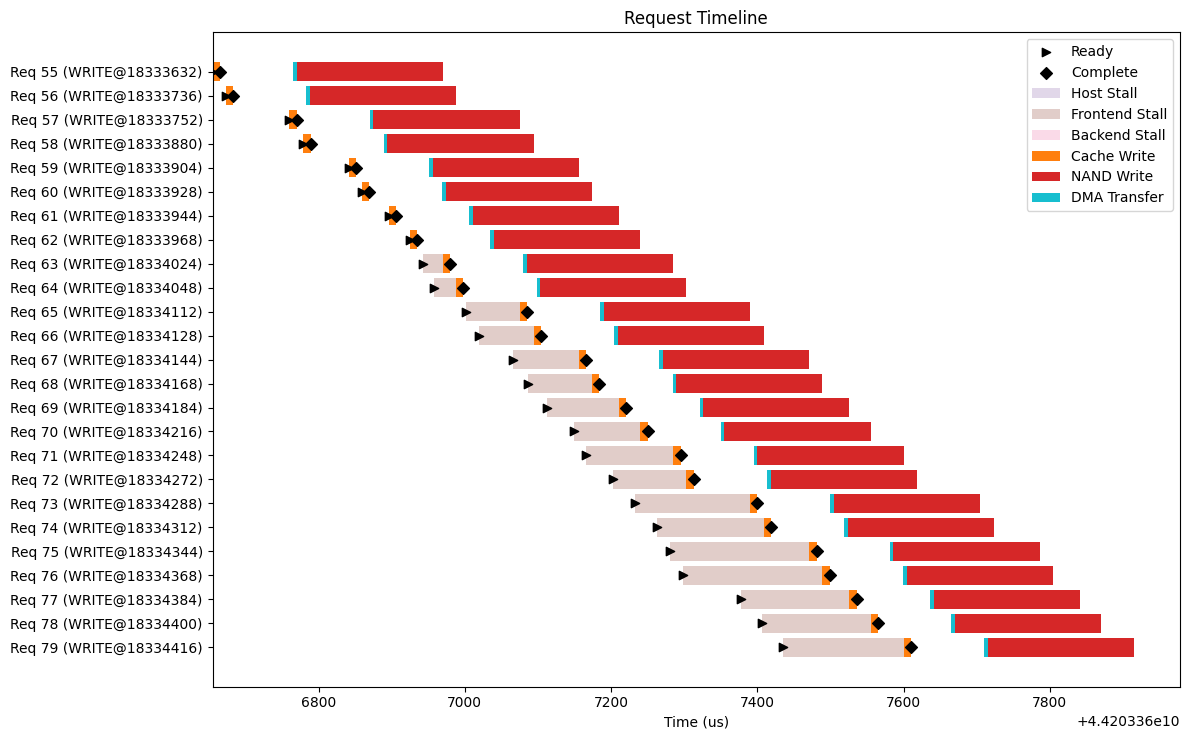

In [ ]:
from request import TraceEvent
import matplotlib.pyplot as plt

sorted_requests = sorted(ssd.completed_requests, key=lambda r: r.tag)

fig, ax = plt.subplots(figsize=(12, len(sorted_requests) * 0.3))

trace_sections = [
    # Inactive / wait sections (lighter tones)
    (
        "Host Stall",
        TraceEvent.READY,
        TraceEvent.NCQ_QUEUED,
        "#c5b0d5",  # lighter purple
        False,
    ),
    (
        "Frontend Stall",
        TraceEvent.NCQ_QUEUED,
        TraceEvent.NCQ_DISPATCHED,
        "#c49c94",  # lighter brown
        False,
    ),
    (
        "Backend Stall",
        TraceEvent.BACKEND_QUEUED,
        TraceEvent.BACKEND_DISPATCHED,
        "#f7b6d2",  # lighter pink
        False,
    ),
    # Active compute sections (strong, original colors)
    (
        "Cache Read",
        TraceEvent.CACHE_READ_START,
        TraceEvent.CACHE_READ_COMPLETE,
        "#1f77b4",  # blue
        True,
    ),
    (
        "Cache Write",
        TraceEvent.CACHE_WRITE_START,
        TraceEvent.CACHE_WRITE_COMPLETE,
        "#ff7f0e",  # orange
        True,
    ),
    (
        "NAND Read",
        TraceEvent.NAND_READ_START,
        TraceEvent.NAND_READ_COMPLETE,
        "#2ca02c",  # green
        True,
    ),
    (
        "NAND Write",
        TraceEvent.NAND_WRITE_START,
        TraceEvent.NAND_WRITE_COMPLETE,
        "#d62728",  # red
        True,
    ),
    (
        "DMA Transfer",
        TraceEvent.DMA_START,
        TraceEvent.DMA_COMPLETE,
        "#17becf",  # cyan
        True,
    ),
]


for i, req in enumerate(sorted_requests):
    trace = req.trace
    for section_name, start_event, end_event, color, is_active in trace_sections:
        if start_event in trace and end_event in trace:
            start_time = trace[start_event]
            end_time = trace[end_event]
            ax.barh(
                i,
                left=start_time,
                width=end_time - start_time,
                height=0.8,
                color=color,
                label=section_name,
                # hatch="//" if not is_active else "",
                alpha=1 if is_active else 0.5,
            )
    # Mark READY and NCQ_COMPLETE events if present
    if TraceEvent.READY in trace:
        ax.scatter(
            trace[TraceEvent.READY],
            i,
            color="black",
            marker=">",
            # s=200,
            label="Ready",
        )
    if TraceEvent.NCQ_COMPLETE in trace:
        ax.scatter(
            trace[TraceEvent.NCQ_COMPLETE],
            i,
            color="black",
            marker="D",
            # s=80,
            label="Complete",
        )

ax.invert_yaxis()
ax.set_yticks(range(len(sorted_requests)))
ax.set_yticklabels(
    [f"Req {req.tag} ({req.type.name}@{req.starting_lba})" for req in sorted_requests]
)

ax.set_xlabel("Time (us)")
ax.set_title("Request Timeline")

# Remove duplicate labels and create legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    bbox_to_anchor=(1, 1),
)

plt.tight_layout()
plt.show()

## Trace parsing test

In [3]:
import pandas as pd

df = pd.read_csv("traces/telegram_precond.csv")

In [11]:
def requests_from_row(row):
    type = None
    match row["rw_flag"]:
        case "R":
            type = RequestType.READ
        case "W":
            type = RequestType.WRITE
        case _:
            raise ValueError(f"Unknown request type: {row['rw_flag']}")
    requests = []
    for block_offset in range(row["size"]):
        requests.append(
            Request(
                type,
                row["sector"] + block_offset,
                row["timestamp"] * 1_000_000,  # convert seconds to microseconds
            )
        )
    return requests


requests = []
for _, row in df.head(200).iterrows():
    requests.extend(requests_from_row(row))

In [5]:
from request import RequestType
from simulator import SSDSimulator

ssd = SSDSimulator()

ssd.run_simulation([req for req in requests if req.type == RequestType.WRITE])
# ssd.print_statistics()

+ Scheduled "REQUEST_ARRIVAL" (seq=0) at t=44203366655.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=1) at t=44203366673.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=2) at t=44203366760.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=3) at t=44203366779.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=4) at t=44203366841.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=5) at t=44203366859.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=6) at t=44203366896.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=7) at t=44203366925.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=8) at t=44203366943.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=9) at t=44203366958.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=10) at t=44203367002.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=11) at t=44203367020.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=12) at t=44203367066.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=13) at t=44203367087.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=14) at t=44203367112.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq=15) at t=44203367149.0 us
+ Scheduled "REQUEST_ARRIVAL" (seq

In [10]:
df.head(20)

,proces,device,rw_flag,sector,size,timestamp
0,dmd-1151,8388608,W,93897440,1024,44186.011543
1,<...>-4922,8388608,W,93897440,1024,44186.012809
2,<...>-4922,8388608,W,93898464,1024,44186.013083
3,dmd-1151,8388608,W,93899488,72,44186.017137
4,kworker/0:0H-5,8388608,W,93899560,1024,44186.017518
5,dmd-1151,8388608,W,93900584,912,44186.018005
6,kworker/0:0H-5,8388608,W,47866368,16,44186.021390
7,kworker/u16:1-5374,8388608,W,47862680,8,44192.765369
8,kworker/u17:3-4922,8388608,W,47862680,8,44192.767704
9,kworker/u16:1-5374,8388608,W,93821424,216,44197.885479
